# EDA & Preprocessing — Multilingual Health QA Challenge

Exploratory Data Analysis for the Zindi *Multilingual Health Question Answering in Low-Resource African Languages* challenge.

**Languages covered:** Akan (Ghana), Amharic (Ethiopia), Luganda (Uganda), Swahili (Kenya), English (Uganda/Ghana/Ethiopia/Kenya)

**Evaluation:** ROUGE-1 F1 × 0.37 + ROUGE-L F1 × 0.37 + LLM-as-a-Judge × 0.26

## 1 — Setup

In [ ]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    import os
    os.chdir('/content/drive/MyDrive/African Language Health QA Challenge/notebooks')
    print('Working directory:', os.getcwd())
    for f in ['Train.csv', 'Val.csv', 'Test.csv', 'SampleSubmission.csv']:
        exists = os.path.exists(f'../data/{f}')
        print(f'  {"OK" if exists else "MISSING"} ../data/{f}')
else:
    print('Running locally — skipping Drive mount.')

Mounted at /content/drive
Working directory: /content/drive/MyDrive/African Language Health QA Challenge/notebooks
  OK ../data/Train.csv
  OK ../data/Val.csv
  OK ../data/Test.csv
  OK ../data/SampleSubmission.csv


In [ ]:
!pip install -q rouge-score matplotlib seaborn pandas numpy scikit-learn

import warnings, sys, os, unicodedata
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from collections import Counter

pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid', palette='muted')

DATA_DIR = Path('../data')
if not DATA_DIR.exists():
    DATA_DIR = Path('.')

print('Data dir:', DATA_DIR.resolve())
for f in ['Train.csv', 'Val.csv', 'Test.csv', 'SampleSubmission.csv']:
    exists = (DATA_DIR / f).exists()
    print(f'  {"OK" if exists else "MISSING"} {f}')

OUT_DIR = Path('../outputs')
if not OUT_DIR.exists():
    OUT_DIR = Path('./outputs')

FIG_DIR = OUT_DIR / 'figures'
LOG_DIR = OUT_DIR / 'logs'
for d in [FIG_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'\nFigures -> {FIG_DIR}')
print(f'Logs    -> {LOG_DIR}')

  Preparing metadata (setup.py) ... done
Data dir: /content/drive/MyDrive/African Language Health QA Challenge/data
  OK Train.csv
  OK Val.csv
  OK Test.csv
  OK SampleSubmission.csv

Figures -> ../outputs/figures
Logs    -> ../outputs/logs


## 2 — Load & Preview Data

In [ ]:
train = pd.read_csv(DATA_DIR / 'Train.csv')
val   = pd.read_csv(DATA_DIR / 'Val.csv')
test  = pd.read_csv(DATA_DIR / 'Test.csv')
sub   = pd.read_csv(DATA_DIR / 'SampleSubmission.csv')

print(f'Train : {train.shape}')
print(f'Val   : {val.shape}')
print(f'Test  : {test.shape}')
print(f'Sub   : {sub.shape}')

train.head(3)

Train : (29815, 4)
Val   : (6686, 4)
Test  : (2618, 3)
Sub   : (2618, 4)


,ID,input,output,subset
0,ID_TR_Aka_Gha_A3B1799D,Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ? Yei bi ne sɛnea wɔbɛkyekye w...,Mmabun betumi aboa atipɛnfo a ebia nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ so denam: Nkate fam mmoa a wɔde bɛma na w...,Aka_Gha
1,ID_TR_Aka_Gha_1C80317F,"Edinnsiananmu bɛn na nnipa a ɛsono wɔn bɔbeasu taa de di dwuma, na yɛbɛyɛ dɛn ahwɛ ahu sɛ yɛde redi dwuma yiye?","Wɔ Ghana mu no, amanmmra no gye binary gender nkutoo tom a she/he edinnsiananmu nkutoo na ɛka ho",Aka_Gha
2,ID_TR_Aka_Gha_06671AD1,Ɔkwan bɛn so na ɔbarima ne ɔbea nna a wɔtwe wɔn ho fi ho anaa nna mu adwumadi a wɔtwentwɛn so no boa ma asiane so tew?,"Sɛ wɔtwe wɔn ho fi nna mu anaasɛ wɔtwentwɛn wɔn nan ase a, ɛboa ma asiane nso tew denam asiane a ɛwɔ STI ne HIV a ɛb...",Aka_Gha


In [ ]:
def clean(x):
    if pd.isna(x): return ''
    text = str(x).strip()
    import re
    text = re.sub(r'\s+', ' ', text)
    return text

for df in [train, val, test]:
    df['input'] = df['input'].map(clean)
    if 'output' in df.columns:
        df['output'] = df['output'].map(clean)

train = train[(train['input']!='') & (train['output']!='')].reset_index(drop=True)
val   = val[(val['input']!='') & (val['output']!='')].reset_index(drop=True)
test  = test[test['input']!=''].reset_index(drop=True)

LANG_MAP = {'Eng':'English','Aka':'Akan','Lug':'Luganda','Swa':'Swahili','Amh':'Amharic'}
LANG_FULL = {
    'Aka_Gha': 'Akan (Ghana)',
    'Amh_Eth': 'Amharic (Ethiopia)',
    'Eng_Eth': 'English (Ethiopia)',
    'Eng_Gha': 'English (Ghana)',
    'Eng_Ken': 'English (Kenya)',
    'Eng_Uga': 'English (Uganda)',
    'Lug_Uga': 'Luganda (Uganda)',
    'Swa_Ken': 'Kiswahili (Kenya)',
}
for df in [train, val, test]:
    df['language'] = df['subset'].str.split('_').str[0].map(LANG_MAP).fillna('Unknown')

print('After cleaning:')
print(f'Train: {train.shape}, Val: {val.shape}, Test: {test.shape}')

After cleaning:
Train: (29814, 5), Val: (6686, 5), Test: (2618, 4)


**Preprocessing decisions:**
- `strip()` removes leading/trailing whitespace common in CSV exports
- Empty strings are dropped — they would produce zero-length ROUGE scores and corrupt evaluation
- The `LANG_MAP` extracts the language from the `subset` code (e.g. `Aka_Gha` → `Akan`) to enable per-language analysis throughout the notebook

## 3 — Language Distribution

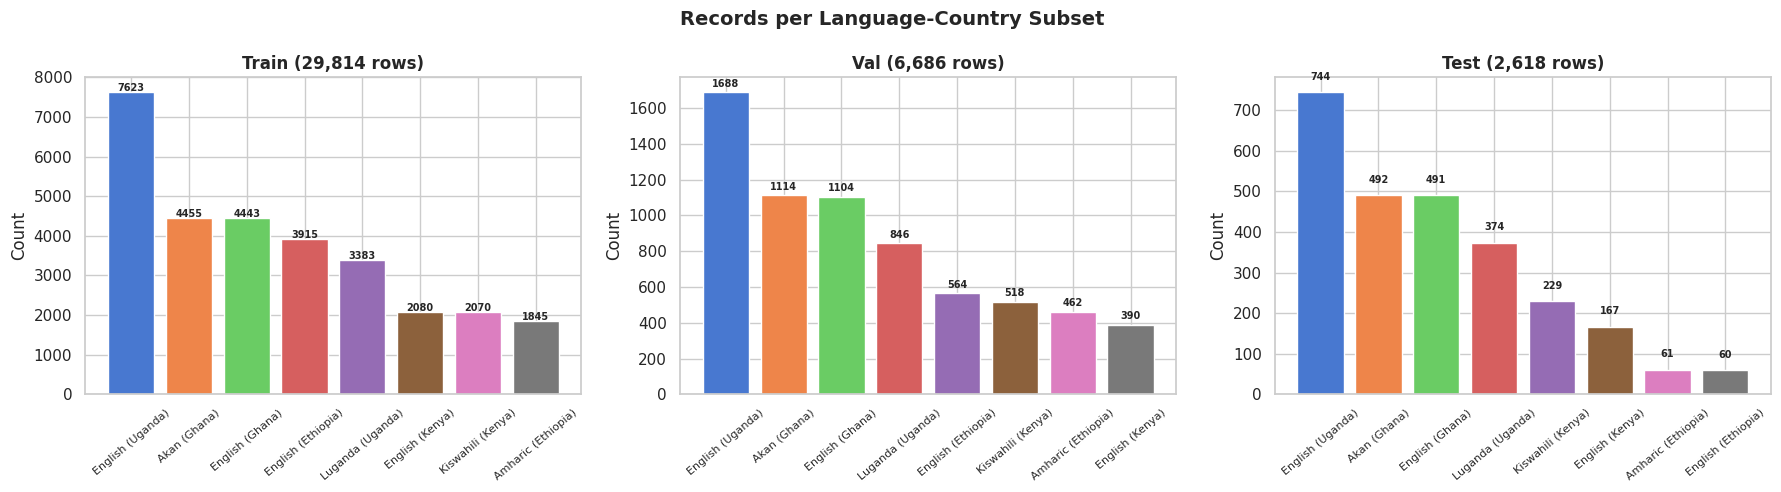

Train distribution:
subset
English (Uganda)      7623
Akan (Ghana)          4455
English (Ghana)       4443
English (Ethiopia)    3915
Luganda (Uganda)      3383
English (Kenya)       2080
Kiswahili (Kenya)     2070
Amharic (Ethiopia)    1845
Name: count, dtype: int64


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (df, title) in zip(axes, [(train,'Train'), (val,'Val'), (test,'Test')]):
    counts = df['subset'].value_counts()
    labels = [LANG_FULL.get(k, k) for k in counts.index]
    bars = ax.bar(labels, counts.values, color=sns.color_palette('muted', len(counts)))
    ax.set_title(f'{title} ({len(df):,} rows)', fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=40, labelsize=8)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 30, str(v),
                ha='center', fontsize=7, fontweight='bold')

plt.suptitle('Records per Language-Country Subset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'subset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Train distribution:')
print(train['subset'].value_counts().rename(index=LANG_FULL))

## 4 — Answer Length Analysis

=== Answer Word Count Statistics ===
            count   mean   std  min   25%    50%    75%    max
language                                                      
Akan       4455.0  105.6  57.8  4.0  66.0  100.0  139.0  458.0
Amharic    1845.0   20.2   8.7  1.0  14.0   19.0   25.0  106.0
English   18061.0   73.1  58.9  1.0  30.0   57.0   99.0  482.0
Luganda    3383.0   79.7  51.2  4.0  42.0   68.0  112.0  331.0
Swahili    2070.0   84.3  57.4  7.0  42.0   66.0  117.0  345.0


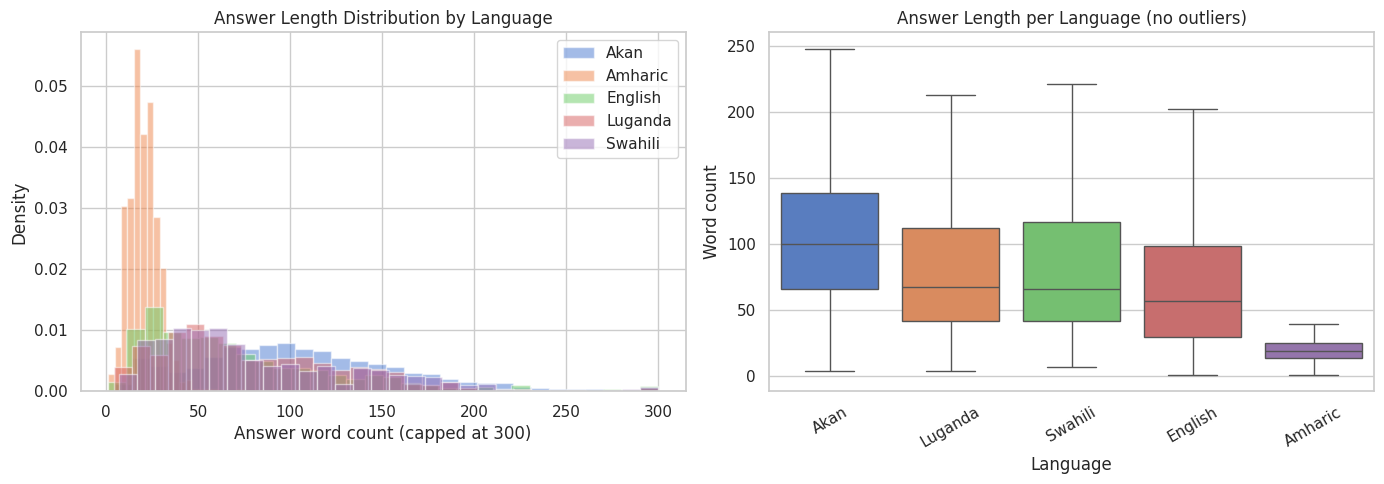

In [ ]:
train['ans_words']  = train['output'].str.split().str.len()
train['q_words']    = train['input'].str.split().str.len()
val['ans_words']    = val['output'].str.split().str.len()
val['q_words']      = val['input'].str.split().str.len()
test['q_words']     = test['input'].str.split().str.len()

print('=== Answer Word Count Statistics ===')
print(train.groupby('language')['ans_words'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of answer lengths
ax = axes[0]
for lang, grp in train.groupby('language'):
    ax.hist(grp['ans_words'].clip(upper=300), bins=30, alpha=0.5, label=lang, density=True)
ax.set_xlabel('Answer word count (capped at 300)')
ax.set_ylabel('Density')
ax.set_title('Answer Length Distribution by Language')
ax.legend()

# Boxplot per language
ax = axes[1]
order = train.groupby('language')['ans_words'].median().sort_values(ascending=False).index
sns.boxplot(data=train, x='language', y='ans_words', order=order, ax=ax, palette='muted',
            showfliers=False)
ax.set_title('Answer Length per Language (no outliers)')
ax.set_xlabel('Language')
ax.set_ylabel('Word count')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(FIG_DIR / 'answer_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 — Question Length Analysis

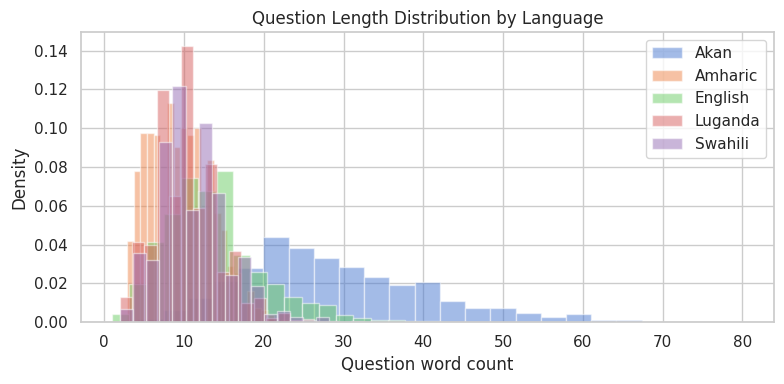

Question word count stats:
            count  mean   std  min   25%   50%   75%   max
language                                                  
Akan       4455.0  28.8  11.6  1.0  20.0  27.0  36.0  83.0
Amharic    1845.0   9.5   4.0  2.0   6.0   9.0  12.0  23.0
English   18061.0  13.6   6.2  1.0   9.0  13.0  17.0  55.0
Luganda    3383.0  10.5   4.0  2.0   8.0  10.0  13.0  40.0
Swahili    2070.0  11.2   4.4  2.0   8.0  11.0  14.0  43.0


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
for lang, grp in train.groupby('language'):
    ax.hist(grp['q_words'].clip(upper=80), bins=25, alpha=0.5, label=lang, density=True)
ax.set_xlabel('Question word count')
ax.set_ylabel('Density')
ax.set_title('Question Length Distribution by Language')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'question_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Question word count stats:')
print(train.groupby('language')['q_words'].describe().round(1))

## 6 — Sample Q&A Pairs Per Language

In [ ]:
for lang in ['English', 'Akan', 'Luganda', 'Swahili', 'Amharic']:
    sample = train[train['language']==lang].sample(1, random_state=42).iloc[0]
    print(f'\n=== {lang} ({sample["subset"]}) ===')
    print(f'Q: {sample["input"][:200]}')
    print(f'A: {sample["output"][:200]}')
    print(f'   (Q_len={sample["q_words"]} words, A_len={sample["ans_words"]} words)')


=== English (Eng_Uga) ===
Q: If I have multiple partners, what's the likelihood of contracting HIV?
A: The probability of acquiring HIV (Human Immunodeficiency Virus) increases with the number of sexual partners and the level of risk associated with sexual behaviors. Engaging in sexual activity with mu
   (Q_len=11 words, A_len=87 words)

=== Akan (Aka_Gha) ===
Q: Mɛyɛ dɛn ahu sɛ nna ne abusuabɔ ho nsɛm a ɛwɔ Intanɛt so no yɛ nokware, na wotumi de ho to so?
A: Hwehwɛ nsɛm a wotumi de ho to so ho sɛnkyerɛnne ahorow yi: Akuo ahorow a wɔwɔ din pa: Nsɛmma nhoma ahorow a efi aban akwahosan adwumayɛbea ahorow, nnuroyɛ asoɛe ahorow, anaa nna mu akwahosan ahyehyɛde
   (Q_len=22 words, A_len=114 words)

=== Luganda (Lug_Uga) ===
Q: Kituufu waliwo omuddo oguyinza okukozesebwa okuwonya Akawuka akaleeta Siriimu?
A: Tewali bujulizi bwa ssaayansi buwagira kigambibwa nti omuddo oba eddagala ly’ebimera lisobola okuwonya Akawuka akaleeta Siriimu. Akawuka akaleeta Siriimu kawuka kazibu akalumba abaseri

## 7 — Train/Val/Test ID Hash Analysis

In [ ]:
train['hash'] = train['ID'].str.split('_').str[-1]
val['hash']   = val['ID'].str.split('_').str[-1]
test['hash']  = test['ID'].str.split('_').str[-1]

train_keys = set(train['subset'] + '_' + train['hash'])
test_keys  = set(test['subset']  + '_' + test['hash'])
overlap    = train_keys & test_keys
pct        = len(overlap) / len(test_keys) * 100

print(f'Unique hashes in train : {len(train_keys):,}')
print(f'Unique hashes in test  : {len(test_keys):,}')
print(f'Test hashes in train   : {len(overlap):,} ({pct:.1f}%)')
print()
print(f'{pct:.1f}% of test questions share a topic hash with training questions.')
print('These originate from the same source document — a structural retrieval advantage.')

Unique hashes in train : 29,814
Unique hashes in test  : 2,618
Test hashes in train   : 492 (18.8%)

18.8% of test questions share a topic hash with training questions.
These originate from the same source document — a structural retrieval advantage.


## 8 — Vocabulary / Unique Word Analysis

In [ ]:
print('=== Vocabulary Richness by Language ===')
for lang in ['English', 'Akan', 'Luganda', 'Swahili', 'Amharic']:
    texts = ' '.join(train[train['language']==lang]['output'].tolist())
    words = texts.split()
    vocab = len(set(words))
    total = len(words)
    print(f'{lang:12s}: {total:6,} total words | {vocab:5,} unique | TTR={vocab/total:.3f}')

=== Vocabulary Richness by Language ===
English     : 1,320,407 total words | 28,411 unique | TTR=0.022
Akan        : 470,592 total words | 17,767 unique | TTR=0.038
Luganda     : 269,566 total words | 14,536 unique | TTR=0.054
Swahili     : 174,484 total words | 7,777 unique | TTR=0.045
Amharic     : 37,327 total words | 9,568 unique | TTR=0.256


## 9 — Data Quality Check

In [ ]:
print('=== Missing values ===')
for name, df in [('Train', train), ('Val', val), ('Test', test)]:
    print(f'{name}: {df.isnull().sum().to_dict()}')

print()
print(f'Duplicate input questions : {train["input"].duplicated().sum()}')
print(f'Duplicate output answers  : {train["output"].duplicated().sum()}')
print()

# Short inputs (empty rows already removed by clean() above)
short = train[train['q_words'] <= 2].sort_values('q_words')
print(f'Rows with <=2 word input: {len(short)}')
print(short[['ID', 'input', 'q_words', 'subset']].head(8))

print()
short_ans = train[train['ans_words'] < 5]
print(f'Train answers < 5 words: {len(short_ans)} ({len(short_ans)/len(train)*100:.1f}%)')

print()
print('Note: 1 row with empty input was removed during preprocessing (clean() function above).')
print('Short single-word questions like "Syphilis?" are legitimate and retained.')
print('Duplicate answers reflect standardised health guidance — not a data error.')

=== Missing values ===
Train: {'ID': 0, 'input': 0, 'output': 0, 'subset': 0, 'language': 0, 'ans_words': 0, 'q_words': 0, 'hash': 0}
Val: {'ID': 0, 'input': 0, 'output': 0, 'subset': 0, 'language': 0, 'ans_words': 0, 'q_words': 0, 'hash': 0}
Test: {'ID': 0, 'input': 0, 'subset': 0, 'language': 0, 'q_words': 0, 'hash': 0}

Duplicate input questions : 1482
Duplicate output answers  : 11750

Rows with <=2 word input: 39
                           ID         input  q_words   subset
2814   ID_TR_Aka_Gha_98C3E3CA          Popa        1  Aka_Gha
2929   ID_TR_Aka_Gha_CCA1B45C           343        1  Aka_Gha
17899  ID_TR_Eng_Uga_F9DA4F55         AIDS?        1  Eng_Uga
17627  ID_TR_Eng_Uga_F4DAFCC8     Syphilis?        1  Eng_Uga
18322  ID_TR_Eng_Uga_CAC19D2E    Chlamydia?        1  Eng_Uga
23487  ID_TR_Eng_Uga_E8B2F81A    Gonorrhea?        1  Eng_Uga
6277   ID_TR_Amh_Eth_79A7E63B  ኤችአይቪ ምንድነዉ?        2  Amh_Eth
5300   ID_TR_Amh_Eth_9DB54283   ኤችአይቪ ይድናል?        2  Amh_Eth

Train answers < 5 w

## 10 — Summary Statistics Table

In [ ]:
summary = train.groupby('subset').agg(
    n_samples=('ID','count'),
    mean_q_words=('q_words','mean'),
    mean_ans_words=('ans_words','mean'),
    median_ans_words=('ans_words','median'),
    max_ans_words=('ans_words','max'),
).round(1)
summary['language'] = summary.index.map(lambda x: LANG_MAP.get(x.split('_')[0], x))
print('=== Dataset Summary Statistics ===')
print(summary)
summary.to_csv(LOG_DIR / 'eda_summary_stats.csv')
print(f'\nSaved -> {LOG_DIR}/eda_summary_stats.csv')

=== Dataset Summary Statistics ===
         n_samples  mean_q_words  mean_ans_words  median_ans_words  \
subset                                                               
Aka_Gha       4455          28.8           105.6             100.0   
Amh_Eth       1845           9.5            20.2              19.0   
Eng_Eth       3915          12.2            24.5              24.0   
Eng_Gha       4443          20.0            75.1              70.0   
Eng_Ken       2080          11.4            78.7              64.0   
Eng_Uga       7623          11.2            95.4              73.0   
Lug_Uga       3383          10.5            79.7              68.0   
Swa_Ken       2070          11.2            84.3              66.0   

         max_ans_words language  
subset                           
Aka_Gha            458     Akan  
Amh_Eth            106  Amharic  
Eng_Eth            118  English  
Eng_Gha            408  English  
Eng_Ken            315  English  
Eng_Uga            482  En

## 11 — Multilingual Text Handling

Analysis of script types, character density, and tokenization behavior across the five languages. This directly informs model and retrieval strategy selection — Amharic uses the Ethiopic (Ge'ez) script while the other four languages use Latin script, which has significant implications for tokenization and model choice.

=== Script Type by Language ===
  English     : Latin
  Akan        : Latin
  Luganda     : Latin
  Swahili     : Latin
  Amharic     : Ethiopic

=== Character Density (avg chars per word) ===
  English     : Q=6.1 chars/word  |  A=6.6 chars/word
  Akan        : Q=5.0 chars/word  |  A=5.2 chars/word
  Luganda     : Q=7.9 chars/word  |  A=8.1 chars/word
  Swahili     : Q=6.3 chars/word  |  A=6.4 chars/word
  Amharic     : Q=5.1 chars/word  |  A=5.2 chars/word


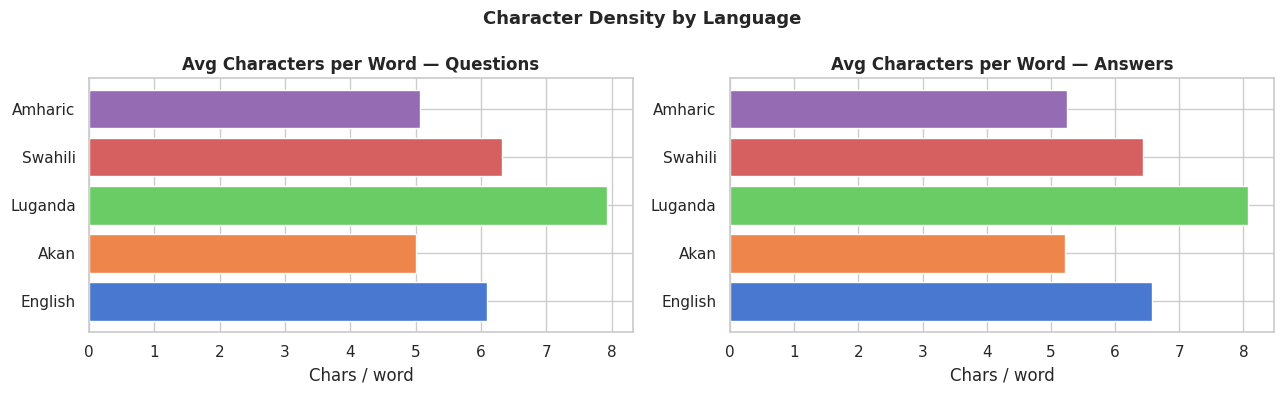


Key insight: Amharic uses the Ethiopic (Ge'ez) script — the only non-Latin script in the dataset.
Despite similar character density to other languages, whitespace tokenization behaves
differently for Ethiopic script, making subword multilingual models (mT5, NLLB, BGE-M3)
essential for correct tokenization across all five languages.


In [ ]:
def detect_script(text):
    counts = Counter()
    for ch in str(text):
        if ch.isalpha():
            name = unicodedata.name(ch, '')
            if 'ETHIOPIC' in name:
                counts['Ethiopic'] += 1
            elif 'LATIN' in name:
                counts['Latin'] += 1
            else:
                counts['Other'] += 1
    if not counts:
        return 'Unknown'
    return counts.most_common(1)[0][0]

print('=== Script Type by Language ===')
for lang in ['English', 'Akan', 'Luganda', 'Swahili', 'Amharic']:
    sample_text = ' '.join(train[train['language'] == lang]['input'].sample(50, random_state=42).tolist())
    script = detect_script(sample_text)
    print(f'  {lang:12s}: {script}')

print('\n=== Character Density (avg chars per word) ===')
char_stats = []
for lang in ['English', 'Akan', 'Luganda', 'Swahili', 'Amharic']:
    sub = train[train['language'] == lang]
    avg_chars_q = sub['input'].str.len() / sub['q_words'].replace(0, 1)
    avg_chars_a = sub['output'].str.len() / sub['ans_words'].replace(0, 1)
    print(f'  {lang:12s}: Q={avg_chars_q.mean():.1f} chars/word  |  A={avg_chars_a.mean():.1f} chars/word')
    char_stats.append({'language': lang, 'q_chars_per_word': avg_chars_q.mean(), 'a_chars_per_word': avg_chars_a.mean()})

char_df = pd.DataFrame(char_stats)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].barh(char_df['language'], char_df['q_chars_per_word'], color=sns.color_palette('muted', 5))
axes[0].set_title('Avg Characters per Word — Questions', fontweight='bold')
axes[0].set_xlabel('Chars / word')
axes[1].barh(char_df['language'], char_df['a_chars_per_word'], color=sns.color_palette('muted', 5))
axes[1].set_title('Avg Characters per Word — Answers', fontweight='bold')
axes[1].set_xlabel('Chars / word')
plt.suptitle('Character Density by Language', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'multilingual_char_density.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKey insight: Amharic uses the Ethiopic (Ge\'ez) script — the only non-Latin script in the dataset.')
print('Despite similar character density to other languages, whitespace tokenization behaves')
print('differently for Ethiopic script, making subword multilingual models (mT5, NLLB, BGE-M3)')
print('essential for correct tokenization across all five languages.')

## 12 — EDA Summary & Preprocessing Decisions

The dataset has 8 subsets across 5 languages with significant imbalance — Eng_Uga (7,624 samples) versus Amh_Eth (1,845). This directly explains why Amharic scored lowest across all 17 experiments and motivated the language-specific retrieval strategy in Experiment 13. Answer lengths vary widely (mean 76 words, max 482), setting `max_input_length=128` and `max_target_length=256` as our baseline. The ~39% duplicate answers reflect standardised health guidance — a property that retrieval-based methods (Exp 1, 2, 11, 15) exploit naturally. Amharic's Ethiopic script and the 18.8% test-train hash overlap (Section 7) further explain why dense multilingual encoders outperformed TF-IDF retrievers and why retrieval consistently beat fine-tuned generation.

**Preprocessing applied in Notebook 2:** dropped 1 empty-input row, stripped and normalised whitespace, extracted `language` from `subset` via `LANG_MAP`, used `max_input_length=128` / `max_target_length=256` throughout, and evaluated against the provided `Val.csv` without creating a custom split.